In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df_generation_Data= pd.read_csv('Plant_2_Generation_Data.csv')
df_generation_Data

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
3,2020-05-15 00:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
4,2020-05-15 00:00:00,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07
...,...,...,...,...,...,...,...
67693,2020-06-17 23:45:00,4136001,q49J1IKaHRwDQnt,0.0,0.0,4157.000000,5.207580e+05
67694,2020-06-17 23:45:00,4136001,rrq4fwE8jgrTyWY,0.0,0.0,3931.000000,1.211314e+08
67695,2020-06-17 23:45:00,4136001,vOuJvMaM2sgwLmb,0.0,0.0,4322.000000,2.427691e+06
67696,2020-06-17 23:45:00,4136001,xMbIugepa2P7lBB,0.0,0.0,4218.000000,1.068964e+08


In [ ]:
df_Weather_Data = pd.read_csv("/content/Plant_2_Weather_Sensor_Data.csv")
df_Weather_Data

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4136001,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,4136001,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,4136001,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,4136001,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,4136001,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0
...,...,...,...,...,...,...
3254,2020-06-17 22:45:00,4136001,iq8k7ZNt4Mwm3w0,23.511703,22.856201,0.0
3255,2020-06-17 23:00:00,4136001,iq8k7ZNt4Mwm3w0,23.482282,22.744190,0.0
3256,2020-06-17 23:15:00,4136001,iq8k7ZNt4Mwm3w0,23.354743,22.492245,0.0
3257,2020-06-17 23:30:00,4136001,iq8k7ZNt4Mwm3w0,23.291048,22.373909,0.0


In [ ]:
generation = pd.read_csv('Plant_2_Generation_Data.csv')
weather = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')

generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'])
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

generation_agg = generation.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER', 'DAILY_YIELD']].sum().reset_index()

df = pd.merge(generation_agg, weather.drop(columns=['PLANT_ID', 'SOURCE_KEY']), on='DATE_TIME')
df

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,48899.938095,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,0.0,0.0,28401.000000,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,0.0,0.0,28401.000000,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,0.0,0.0,28401.000000,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,0.0,0.0,26516.000000,26.596148,25.088210,0.0
...,...,...,...,...,...,...,...
3254,2020-06-17 22:45:00,0.0,0.0,93040.000000,23.511703,22.856201,0.0
3255,2020-06-17 23:00:00,0.0,0.0,93040.000000,23.482282,22.744190,0.0
3256,2020-06-17 23:15:00,0.0,0.0,93040.000000,23.354743,22.492245,0.0
3257,2020-06-17 23:30:00,0.0,0.0,93040.000000,23.291048,22.373909,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3259 entries, 0 to 3258
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3259 non-null   datetime64[ns]
 1   DC_POWER             3259 non-null   float64       
 2   AC_POWER             3259 non-null   float64       
 3   DAILY_YIELD          3259 non-null   float64       
 4   AMBIENT_TEMPERATURE  3259 non-null   float64       
 5   MODULE_TEMPERATURE   3259 non-null   float64       
 6   IRRADIATION          3259 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 178.4 KB


In [ ]:
df.describe()

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3259,3259.000000,3259.000000,3259.000000,3259.000000,3259.000000,3259.000000
mean,2020-06-01 00:04:35.053697536,5124.648465,5011.974903,68443.535809,28.069400,32.772408,0.232737
min,2020-05-15 00:00:00,0.000000,0.000000,0.000000,20.942385,20.265123,0.000000
25%,2020-05-23 12:07:30,0.000000,0.000000,18698.245238,24.602135,23.716881,0.000000
50%,2020-06-01 00:00:00,494.427143,477.536667,73875.000000,26.981263,27.534606,0.019040
75%,2020-06-09 12:07:30,11048.773333,10795.727619,110975.223810,31.056757,40.480653,0.438717
max,2020-06-17 23:45:00,26630.506667,25979.760476,162876.000000,39.181638,66.635953,1.098766
std,NaN,6462.118509,6317.872611,48505.077129,4.061556,11.344034,0.312693


In [ ]:
df['AC_POWER'].describe()

,AC_POWER
count,3259.000000
mean,5011.974903
std,6317.872611
min,0.000000
25%,0.000000
50%,477.536667
75%,10795.727619
max,25979.760476


In [ ]:
df.isnull().sum()

,0
DATE_TIME,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0
IRRADIATION,0


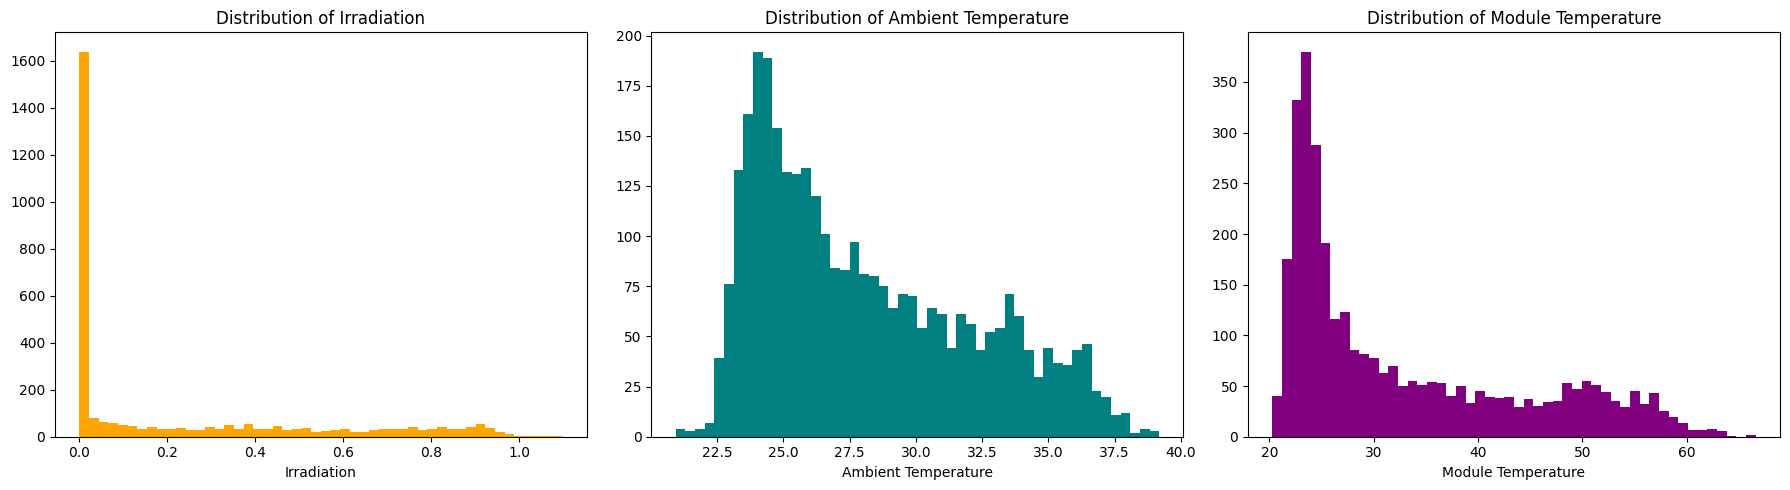

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['IRRADIATION'], bins=50, color='orange')
axes[0].set_title('Distribution of Irradiation')
axes[0].set_xlabel('Irradiation')

axes[1].hist(df['AMBIENT_TEMPERATURE'], bins=50, color='teal')
axes[1].set_title('Distribution of Ambient Temperature')
axes[1].set_xlabel('Ambient Temperature')

axes[2].hist(df['MODULE_TEMPERATURE'], bins=50, color='purple')
axes[2].set_title('Distribution of Module Temperature')
axes[2].set_xlabel('Module Temperature')

plt.tight_layout()
plt.show()

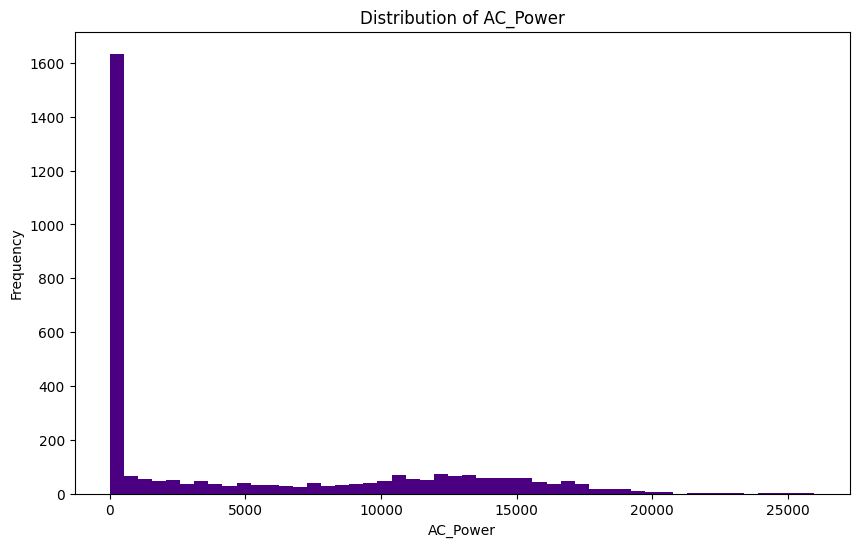

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['AC_POWER'], bins=50, color='indigo')
plt.xlabel('AC_Power')
plt.ylabel('Frequency')
plt.title('Distribution of AC_Power')
plt.show()

In [ ]:
Q1 = df['AC_POWER'].quantile(0.25)
Q3 = df['AC_POWER'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['AC_POWER'] < lower) | (df['AC_POWER'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 0


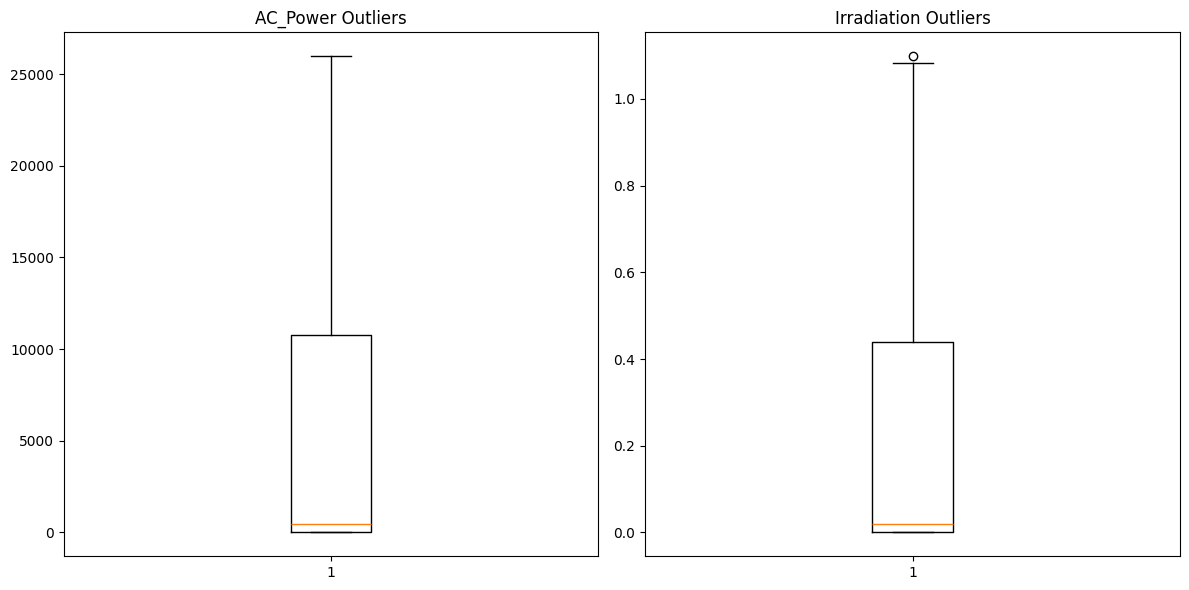

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].boxplot(df['AC_POWER'])
axes[0].set_title('AC_Power Outliers')

axes[1].boxplot(df['IRRADIATION'])
axes[1].set_title('Irradiation Outliers')

plt.tight_layout()
plt.show()

In [ ]:
X = df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']]
y = df['AC_POWER']

In [ ]:
X.corr()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
AMBIENT_TEMPERATURE,1.000000,0.847273,0.667639
MODULE_TEMPERATURE,0.847273,1.000000,0.946886
IRRADIATION,0.667639,0.946886,1.000000


In [ ]:
inverter_count = generation.groupby('DATE_TIME')['SOURCE_KEY'].nunique().reset_index()
inverter_count.columns = ['DATE_TIME', 'active_inverters']
df = pd.merge(df, inverter_count, on='DATE_TIME')

df['active_inverters'].value_counts()

,count
active_inverters,
22,2355
18,840
12,64


In [ ]:
df_clean = df[df['active_inverters'] == 22].copy()

df_clean['Irradiation_x_ModuleTemp'] = df_clean['IRRADIATION'] * df_clean['MODULE_TEMPERATURE']

X = df_clean[['AMBIENT_TEMPERATURE', 'IRRADIATION', 'Irradiation_x_ModuleTemp']]
y = df_clean['AC_POWER']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Training model...")
model = LinearRegression()
model.fit(X_train, y_train)

Training model...


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)
r2 = r2_score(y_test, y_pred)
print(f"R-squared Score: {r2:.2f}\n")

R-squared Score: 0.89



In [ ]:
plot_df = pd.DataFrame({
    'AMBIENT_TEMPERATURE': X_test['AMBIENT_TEMPERATURE'],
    'Actual AC_Power': y_test,
    'Predicted AC_Power': y_pred
})

fig = px.scatter(
    plot_df, x='AMBIENT_TEMPERATURE', y=['Actual AC_Power', 'Predicted AC_Power'],
    title='AC Power vs Ambient Temperature',
    color_discrete_sequence=['indigo', 'gray']
)
fig.update_layout(
    xaxis_title='Ambient Temperature',
    yaxis_title='AC Power',
    legend_title='',
    width=800, height=700
)
fig.show()

In [ ]:
fig = px.scatter(
    x=y_test, y=y_pred,
    labels={'x': 'Actual AC_Power', 'y': 'Predicted AC_Power'},
    title='Actual vs Predicted AC_Power'
)
fig.update_traces(marker=dict(color='indigo'), name='Predictions', showlegend=True)

fig.add_scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    line=dict(color='gray', width=2),
    name='Perfect Prediction'
)

fig.update_layout(width=800, height=700)
fig.show()

In [ ]:
import pandas as pd
import numpy as np

#ENCODUNG
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

df['month'] = df['DATE_TIME'].dt.month
df['day'] = df['DATE_TIME'].dt.day
df['day_of_year'] = df['DATE_TIME'].dt.dayofyear
df['day_of_week'] = df['DATE_TIME'].dt.dayofweek

# Cyclical Encoding  (1-12)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

# Cyclical Encoding  (1-365)
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.0)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.0)

df.drop(columns=['month', 'DATE_TIME'], inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1884, 3)
(471, 3)
(1884,)
(471,)


In [ ]:
print(X_train.shape)
print(X_test.shape)

(1884, 3)
(471, 3)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_linear = r2_score(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

print("Linear Regression")
print("R²:", r2_linear)
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)

Linear Regression
R²: 0.8913755340218098
MAE: 973.6971592559978
RMSE: 2007.782021504694


In [ ]:
fig = px.scatter(
    x=y_test,
    y=y_pred_linear,
    labels={
        'x': 'Actual AC_Power',
        'y': 'Predicted AC_Power'
    },
    title='Linear Regression - Actual vs Predicted AC_Power'
)

fig.add_scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    name='Perfect Prediction'
)

fig.update_layout(width=800, height=700)

fig.show()

In [ ]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel='rbf',
    C=100,
    gamma='scale'
)

svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

In [ ]:
r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print("SVR")
print("R²:", r2_svr)
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)

SVR
R²: 0.9024816107885794
MAE: 744.335008065943
RMSE: 1902.3744015245131


In [ ]:
fig = px.scatter(
    x=y_test,
    y=y_pred_svr,
    labels={
        'x': 'Actual AC_Power',
        'y': 'Predicted AC_Power'
    },
    title='SVR - Actual vs Predicted AC_Power'
)

fig.add_scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    name='Perfect Prediction'
)

fig.update_layout(width=800, height=700)

fig.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest")
print("R²:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
R²: 0.9063813244295887
MAE: 672.2203486098294
RMSE: 1863.9488067078619


In [ ]:
fig = px.scatter(
    x=y_test,
    y=y_pred_rf,
    labels={
        'x': 'Actual AC_Power',
        'y': 'Predicted AC_Power'
    },
    title='Random Forest - Actual vs Predicted AC_Power'
)

fig.add_scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    name='Perfect Prediction'
)

fig.update_layout(width=800, height=700)

fig.show()

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'SVR',
        'Random Forest'
    ],
    'R²': [
        r2_linear,
        r2_svr,
        r2_rf
    ],
    'MAE': [
        mae_linear,
        mae_svr,
        mae_rf
    ],
    'RMSE': [
        rmse_linear,
        rmse_svr,
        rmse_rf
    ]
})

results

,Model,R²,MAE,RMSE
0,Linear Regression,0.891376,973.697159,2007.782022
1,SVR,0.902482,744.335008,1902.374402
2,Random Forest,0.906381,672.220349,1863.948807


In [ ]:
best_model = results.loc[results['R²'].idxmax()]

print("Best Model:", best_model['Model'])
print("R²:", best_model['R²'])
print("MAE:", best_model['MAE'])
print("RMSE:", best_model['RMSE'])

Best Model: Random Forest
R²: 0.9063813244295887
MAE: 672.2203486098294
RMSE: 1863.9488067078619


In [ ]:
df.head()

,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,active_inverters,day,day_of_year,day_of_week,month_sin,month_cos,day_of_year_sin,day_of_year_cos
0,0.0,0.0,48899.938095,27.004764,25.060789,0.0,22,15,136,4,0.5,-0.866025,0.717677,-0.696376
1,0.0,0.0,28401.000000,26.880811,24.421869,0.0,22,15,136,4,0.5,-0.866025,0.717677,-0.696376
2,0.0,0.0,28401.000000,26.682055,24.427290,0.0,22,15,136,4,0.5,-0.866025,0.717677,-0.696376
3,0.0,0.0,28401.000000,26.500589,24.420678,0.0,22,15,136,4,0.5,-0.866025,0.717677,-0.696376
4,0.0,0.0,26516.000000,26.596148,25.088210,0.0,22,15,136,4,0.5,-0.866025,0.717677,-0.696376
